# Macro Watch — Weekly Cross-Asset Brief

Programmatic ingestion, alignment, analytics and visualization of macro-financial data for a weekly market-regime overview.

**Sources:** MoF Japan (JGB yields), FRED (US rates / breakevens / WTI), Yahoo Finance (equity indices + gold).

**Pipeline:** `data_loader` → `analytics` → `visualizer` → Markdown summary.

In [1]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import pandas as pd

# Make the package importable when running from inside macro_watch/.
sys.path.insert(0, str(Path.cwd().parent))

from macro_watch import analytics, visualizer
from macro_watch.data_loader import MacroDataLoader

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
visualizer.apply_style()

## 1. Ingest & cache

Instantiate the loader, refresh the Parquet cache and prepare the aligned business-day panel. Set `REFRESH = False` to reuse the cache and avoid hitting the network.

In [2]:
REFRESH = False  # set True to re-fetch all sources and rebuild the Parquet cache

loader = MacroDataLoader(cache_dir=Path.cwd().parent / "data_cache")
panel = loader.load(refresh=REFRESH)

print(f"Panel: {panel.shape[0]:,} rows x {panel.shape[1]} cols")
print(f"Coverage: {panel.index.min().date()} -> {panel.index.max().date()}")
panel.tail()

Panel: 16,819 rows x 12 cols
Coverage: 1962-01-02 -> 2026-06-19


,US2Y,US10Y,US10Y_BEI,JP2Y,JP5Y,JP10Y,WTI,GOLD,SPX,NDX,N225,TOPIX
date,,,,,,,,,,,,
2026-06-15,4.070,4.470,2.320,1.409,1.901,2.589,84.650,"4,328.000","7,554.290","26,683.939","69,317.500",NaN
2026-06-16,4.050,4.430,2.290,1.414,1.945,2.655,84.650,"4,330.900","7,511.350","26,376.340","69,404.500",NaN
2026-06-17,4.200,4.490,2.260,1.398,1.897,2.613,84.650,"4,358.900","7,420.100","26,021.660","69,902.250",NaN
2026-06-18,4.200,4.490,2.250,1.400,1.898,2.628,84.650,"4,224.100","7,500.580","26,517.930","71,053.492",NaN
2026-06-19,4.200,4.490,2.250,1.400,1.898,2.628,84.650,"4,172.900","7,500.580","26,517.930","71,250.062",NaN


## 2. Analytics

Derive real yields and curve slopes, then compute the current-week summary: levels, week-over-week (WoW) changes, and volatility-normalized z-scores (1-week and 4-week horizons).

In [3]:
summary = analytics.weekly_summary(panel)
print(f"As of: {summary.as_of.date()}")

fmt = {"Level": "{:,.3f}", "WoW": "{:+,.3f}", "Z_1W": "{:+.2f}", "Z_4W": "{:+.2f}"}
summary.table.style.format(fmt).background_gradient(
    subset=["Z_1W", "Z_4W"], cmap="RdBu_r", vmin=-3, vmax=3
)

As of: 2026-06-19


,Level,WoW,Z_1W,Z_4W,Type
US2Y,4.200,+0.110,+0.98,+0.31,Yield/Spread
US10Y,4.490,+0.010,+0.10,-0.35,Yield/Spread
US10Y_BEI,2.250,-0.060,-1.25,-1.56,Yield/Spread
JP2Y,1.400,-0.017,-0.47,-0.59,Yield/Spread
JP5Y,1.898,-0.040,-0.65,-1.04,Yield/Spread
JP10Y,2.628,-0.015,-0.19,-0.75,Yield/Spread
WTI,84.650,-0.046,-0.44,-0.82,Price
GOLD,"4,172.900",-0.010,-0.25,-1.01,Price
SPX,"7,500.580",+0.009,+0.45,+0.09,Price
NDX,"26,517.930",+0.024,+0.84,+0.11,Price


In [4]:
# Latest rolling correlations for the key macro pairs.
summary.correlations.dropna(how="all").iloc[[-1]].T.rename(columns={summary.correlations.dropna(how='all').index[-1]: 'rho'})

date,rho
RealYield_vs_Gold_30d,-0.301
RealYield_vs_Gold_60d,-0.330
WTI_vs_BEI_30d,0.465
WTI_vs_BEI_60d,0.587
SPX_vs_US10Y_30d,-0.678
SPX_vs_US10Y_60d,-0.625


## 3. Visualization

### 3.1 Weekly cross-asset momentum (z-score heatmap)

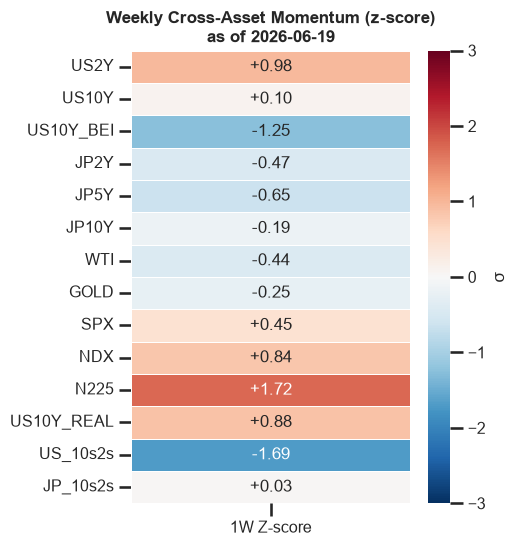

In [5]:
_ = visualizer.plot_weekly_heatmap(panel)

### 3.2 Yield-curve shifts (current vs 1W vs 1M)

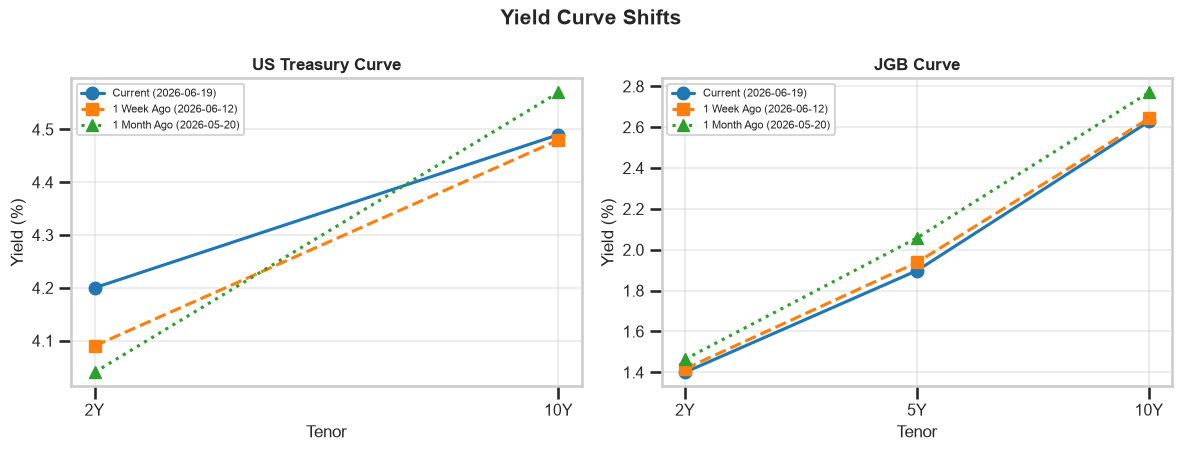

In [6]:
_ = visualizer.plot_curve_shifts(panel)

### 3.3 Macro decoupling tracker (real rates / gold & WTI / breakevens)

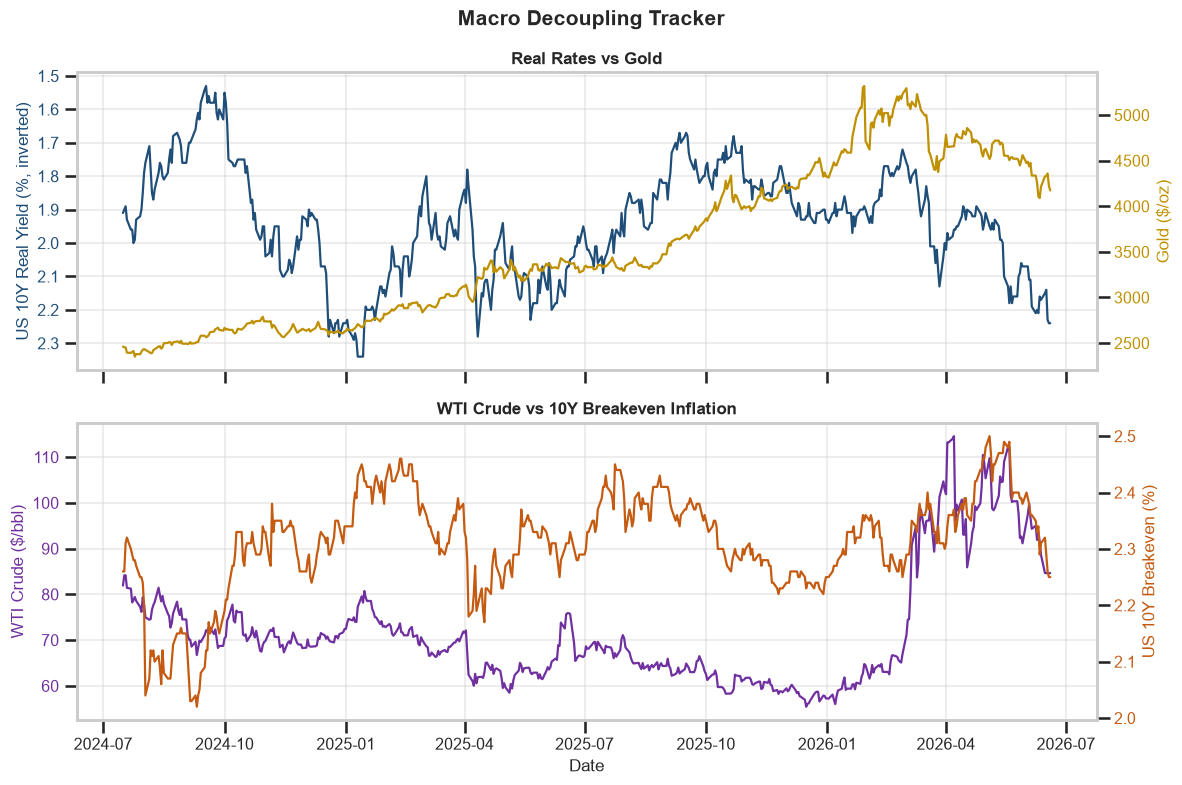

In [7]:
_ = visualizer.plot_decoupling(panel)

### 3.4 Rolling correlations (30d / 60d)

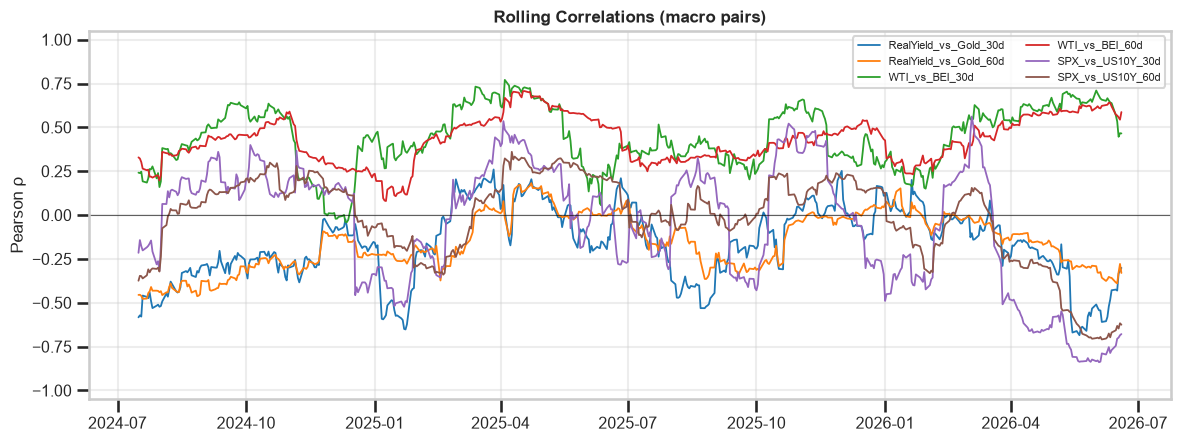

In [8]:
_ = visualizer.plot_rolling_correlations(summary.correlations)

## 4. Weekly summary table (Markdown)

Open / High / Low / Close over the final week, with WoW change and 1-week z-score for the last session.

In [9]:
from IPython.display import Markdown

report = summary.ohlc.join(summary.table[["WoW", "Z_1W", "Type"]])
report = report[["Open", "High", "Low", "Close", "WoW", "Z_1W", "Type"]].round(3)

md = (
    f"### Weekly Macro Brief — week ending {summary.as_of.date()}\n\n"
    + report.to_markdown(floatfmt="+.3f")
)
Markdown(md)

### Weekly Macro Brief — week ending 2026-06-19

|            |       Open |       High |        Low |      Close |      WoW |     Z_1W | Type         |
|:-----------|-----------:|-----------:|-----------:|-----------:|---------:|---------:|:-------------|
| US2Y       |     +4.070 |     +4.200 |     +4.050 |     +4.200 |   +0.110 |   +0.976 | Yield/Spread |
| US10Y      |     +4.470 |     +4.490 |     +4.430 |     +4.490 |   +0.010 |   +0.101 | Yield/Spread |
| US10Y_BEI  |     +2.320 |     +2.320 |     +2.250 |     +2.250 |   -0.060 |   -1.245 | Yield/Spread |
| JP2Y       |     +1.409 |     +1.414 |     +1.398 |     +1.400 |   -0.017 |   -0.467 | Yield/Spread |
| JP5Y       |     +1.901 |     +1.945 |     +1.897 |     +1.898 |   -0.040 |   -0.648 | Yield/Spread |
| JP10Y      |     +2.589 |     +2.655 |     +2.589 |     +2.628 |   -0.015 |   -0.186 | Yield/Spread |
| WTI        |    +84.650 |    +84.650 |    +84.650 |    +84.650 |   -0.046 |   -0.441 | Price        |
| GOLD       |  +4328.000 |  +4358.900 |  +4172.900 |  +4172.900 |   -0.010 |   -0.253 | Price        |
| SPX        |  +7554.290 |  +7554.290 |  +7420.100 |  +7500.580 |   +0.009 |   +0.453 | Price        |
| NDX        | +26683.939 | +26683.939 | +26021.660 | +26517.930 |   +0.024 |   +0.838 | Price        |
| N225       | +69317.500 | +71250.062 | +69317.500 | +71250.062 |   +0.076 |   +1.724 | Price        |
| TOPIX      |   +nan     |   +nan     |   +nan     |   +nan     | +nan     | +nan     | Price        |
| US10Y_REAL |     +2.150 |     +2.240 |     +2.140 |     +2.240 |   +0.070 |   +0.885 | Yield/Spread |
| US_10s2s   |    +40.000 |    +40.000 |    +29.000 |    +29.000 |  -10.000 |   -1.688 | Yield/Spread |
| JP_10s2s   |   +118.000 |   +124.100 |   +118.000 |   +122.800 |   +0.200 |   +0.032 | Yield/Spread |

In [10]:
# Persist the brief alongside the cache for distribution.
out_path = Path.cwd().parent / "data_cache" / f"weekly_brief_{summary.as_of.date()}.md"
out_path.write_text(md)
print(f"Saved -> {out_path}")

Saved -> /Users/keitafujie/Documents/macro/data_cache/weekly_brief_2026-06-19.md
